In [44]:
import torch
import torchvision
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from skimage import io
from PIL import Image
from torchvision.transforms import v2

Note: you may need to restart the kernel to use updated packages.


In [16]:
class LoadDataset(Dataset):
    """Load dataset."""

    def __init__(self, df, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["files"]
        label = self.df.iloc[idx]["label_binary"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [3]:
### read in the label df ###
label_df = pd.read_csv("../dataset/dataset_split.csv").loc[:,["files","label_binary"]]

## train_test_validation split, the dataset is unbalanced
## There are  15527 healthy samples.
## There are  43784 disease samples.
## approx. 20%-80% healthy-disease split
## Split instances into majority vs minority class/classes
df_majority = label_df[label_df["label_binary"] == 'disease']
df_minority = label_df[label_df["label_binary"] == 'healthy']

# Undersampling majority class: so there is a 40%-60% healthy-disease split
## https://machinelearningmastery.com/navigating-imbalanced-datasets-with-pandas-and-scikit-learn/

## calculate number of desired majority class samples: Maj / (Maj+Min) = 0.6 --> round(.6*Min/.4) 
df_majority_downsampled = df_majority.sample(n=int(.6/.4*len(df_minority)), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority])

train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced['label_binary'], random_state=0)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_binary'], random_state=0)

train_df.iloc[0,0]

'/users/aflemis1/AI-and-Deep-Learning-Group-8--6165/dataset/PlantVillage/Pepper,_bell___healthy/eed1b6d4-c01c-4b3f-8aba-77ebc730b2f9___JR_HL 7907.JPG'

In [ ]:
train_df['csv']

In [17]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # automatically scales to [0,1]
])


train_dataset = LoadDataset(train_df, transform=transform)
val_dataset   = LoadDataset(val_df, transform=transform)
test_dataset  = LoadDataset(test_df, transform=transform)


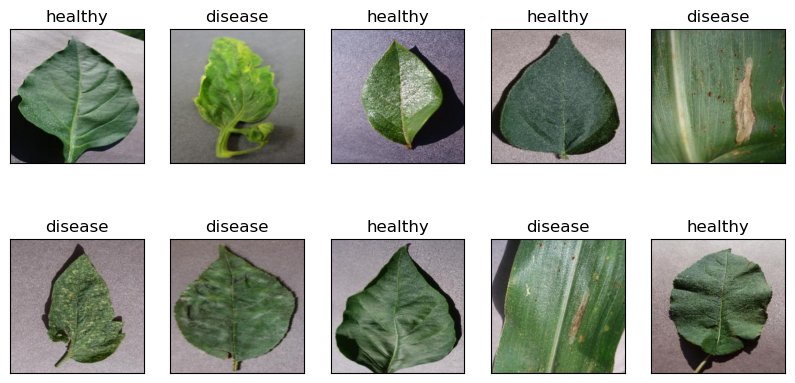

In [41]:
def show_img(x, title="", bot=""): ## bot is bottom
    plt.imshow(x)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.xlabel(bot)


plt.figure(figsize = (10,5))
for i, sample_label in enumerate(train_dataset):
    if i < 10:
        plt.subplot(2,5,i+1)
        show_img(sample_label[0].permute(1, 2, 0).numpy(), sample_label[1])
    else:
        break
plt.show()

In [93]:
data_augmentation = v2.Compose([
    transforms.v2.RandomHorizontalFlip(p=0.5),
    transforms.v2.RandomVerticalFlip(p=0.5),
    transforms.v2.RandomRotation(degrees = (-.1,.1)),
    #transforms.v2.RandomZoomOut(p=.5),
    transforms.v2.ColorJitter(brightness = (.5,1), contrast = 0.1,
                              saturation = 0.1, hue = 0.1)
])

<Figure size 1000x1000 with 0 Axes>

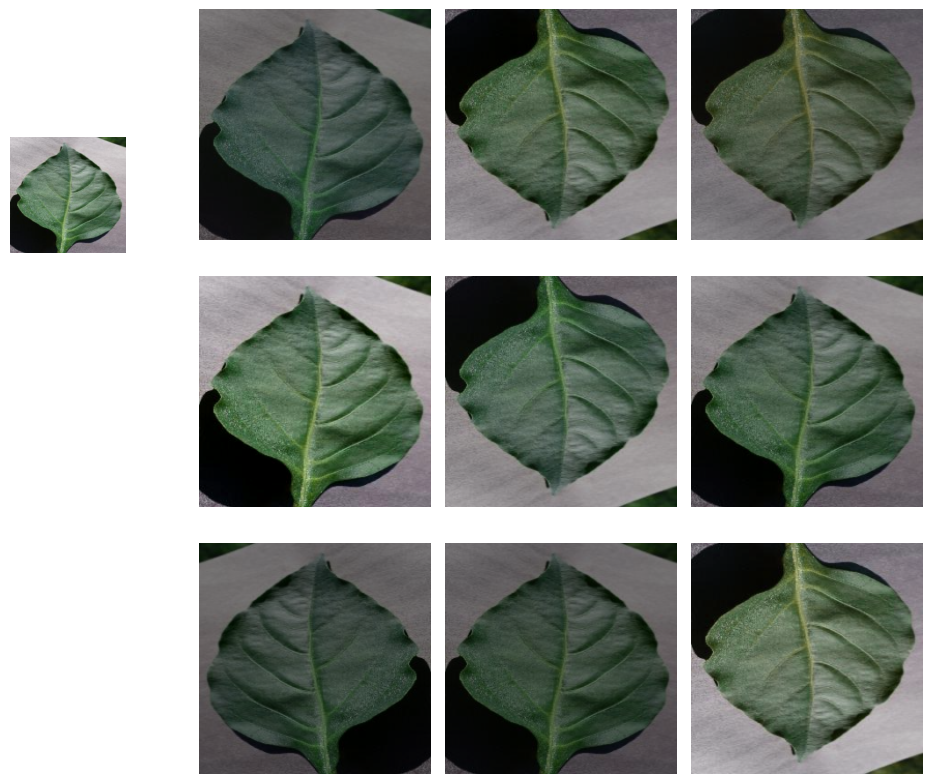

In [94]:


plt.figure(figsize=(10, 10))

for i, image_label in enumerate(train_dataset):
    plt.figure(figsize=(10,8))
    plt.subplot(6, 4, 5)
    plt.imshow(image_label[0].permute(1, 2, 0).numpy())
    plt.axis("off")


    for j in range(9):
        ax = plt.subplot(3, 4, int(j/3)*4 + 2 + (j % 3))

        show_img(data_augmentation(image_label[0]).permute(1,2,0).numpy(), "")

        plt.tight_layout()
        plt.axis("off")
    plt.tight_layout()
    if i != 1:
        break

TypeError: LoadDataset.__init__() got an unexpected keyword argument 'csv_file'